# 08 - The agents on the inverter: a dynamic inverter model in the loop

Every notebook so far treats a PV inverter as a static device: OpenDSS assumes it delivers
the reactive power its curve asks for, instantly and exactly, and the agent that sets the
curve is a PyTorch network called from Python. This notebook moves both onto a dynamic
inverter model. The four far units of feeder 1 (buses 7, 9, 10 and 11, where the OPF of
notebook 04 puts most of the absorption) are replaced by inverter models running in Typhoon
HIL, and the trained actor of notebook 06 is compiled into each of them as a C block, so that
every 15 minutes each inverter decides its own curve points from what it measures at its own
terminal. The other five units stay in OpenDSS and are decided by the same network in Python.
OpenDSS and Typhoon exchange bus voltages and inverter powers about once a second, in the
manner of the real-time co-simulation of Wagle et al. (IET GTD 2023), and the day is compared
with the OpenDSS-only run of notebook 06.

Two things come out of it. Over the sunniest day of the year the agents on the dynamic
inverters reproduce the study's voltages and reactive powers to within 0.0005 pu and about
1 kvar, so the static assumption and the Python agent were fair stand-ins at 15-minute
resolution. Between two 15-minute points there are a few seconds the study never saw, and
they are shown here once.

The Typhoon side ran in Virtual HIL, the software-only mode of Typhoon HIL Control Center
2023.4, so nothing here is real time. The cells that export the network, build the model and
run the loop execute only when the Typhoon software and its Python API are installed;
otherwise the notebook reads the saved results in `results/` and produces the same figures.

In [1]:
# Paths: this notebook runs from notebooks/, the modules live in src/ and every
# generated file in results/, so the working directory is moved there once.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    sys.path.insert(0, os.path.abspath(os.path.join(os.pardir, "src")))
    os.makedirs(os.path.join(os.pardir, "results"), exist_ok=True)
    os.chdir(os.path.join(os.pardir, "results"))

import importlib.util, math, time
import numpy as np
import pandas as pd
import h5py
import torch
import matplotlib.pyplot as plt

import simulate as sim
import agents
from env import VoltVarEnv, EnvConfig, curve_to_action, action_to_curve, dss

T_NB0 = time.perf_counter()
plt.rcParams.update({"font.size": 10, "axes.titlesize": 10, "axes.labelsize": 10,
                     "legend.fontsize": 9, "figure.dpi": 100})

# The Typhoon parts run only with the software present: its Python API importable and
# TYPHOONPATH pointing at the installation (e.g. C:\Program Files\Typhoon HIL Control Center 2023.4 sp1).
HAVE_TYPHOON = importlib.util.find_spec("typhoon") is not None and bool(os.environ.get("TYPHOONPATH"))
REBUILD = False          # True: export the network and recompile the Typhoon model even if it exists
RERUN = False            # True: rerun the co-simulation even if results/hil_day171.csv exists
print("Typhoon HIL API available:", HAVE_TYPHOON)

DAY, SEED = 171, 0                       # the sunniest day of the year; seed 0, best checkpoint
UNITS = (7, 9, 10, 11)                   # the far units, handed over to Typhoon
IDX = [sim.PV_BUSES.index(b) for b in UNITS]
DSS_IDX = [j for j in range(9) if j not in IDX]
VN, FN = 400.0, 50.0                     # the Typhoon inverter is a 400 V, 50 Hz unit
P_TYPH, SN_TYPH = 250e3, 275e3           # 250 kW panel, 1.1 x Pmpp inverter, the study's ratio
SCALE = {b: sim.PV_KW[j] * 1e3 / P_TYPH for b, j in zip(UNITS, IDX)}   # 740/250 for all four
HANDSHAKES, WAIT_MS = 8, 1000
CAPTURE_AT = "11:30"                     # the step whose first seconds are recorded
print("units and scale to feeder size:", {b: round(s, 2) for b, s in SCALE.items()})

Typhoon HIL API available: True
units and scale to feeder size: {7: np.float64(2.96), 9: np.float64(2.96), 10: np.float64(2.96), 11: np.float64(2.96)}


## 1. The setup: two homes for one network

OpenDSS keeps the whole feeder, its loads, the transformer and five of the nine PV units,
exactly as in notebook 06. The units at buses 7, 9, 10 and 11 keep their PVSystem element but
lose their InvControl: their P and Q are written in from outside. Outside is Typhoon HIL,
running four copies of one inverter model: a 250 kW PV panel, the library block
"PV inverter (Average)" (DC-link control, MPPT, current control, 275 kVA, 400 V, 50 Hz), a
volt-var block that reads the terminal voltage through a 1 s filter (standing in for the
open-loop response time of IEEE 1547-2018, whose Category B default is 5 s), and an agent
block. The agent block holds the actor of notebook 06 with its weights, reads the unit's own
terminal voltage, P and Q (in pu of its kVA), the time of day and the irradiance, appends its
one-hot unit tag, and writes V3, V4, Q4 into the volt-var block. It computes only when a
`tick` input changes, the 15-minute clock, and holds its answer in between.

Two clocks run in one script:

* **Every 15 minutes** the tick is raised. The four Typhoon agents decide inside Typhoon; the
  five OpenDSS agents are the same network run in PyTorch on their OpenDSS bus values. The new
  loads and irradiance of the step are applied on both sides.
* **About once a second** the two programs exchange: OpenDSS solves the feeder with the four
  Typhoon units' latest P and Q and hands their bus voltages to Typhoon's grid sources (nudged
  so each inverter's measured terminal equals its bus, since the block measures behind a small
  internal impedance); Typhoon runs for a second; its P and Q, scaled from the 250 kW unit to
  the 740 kW unit of the study, go back into the PVSystems. Eight exchanges per step, then the
  settled values are recorded.

The reference is the OpenDSS-only run of seed 0 in notebook 06, before the safety layer. Night
steps are skipped.

## 2. Putting the network on the inverter

The actor is a small network, 15 inputs, two hidden layers of 128, three outputs (the means;
the log-standard deviations are dropped, the deterministic policy is used). Its weights are
written as C arrays into `agent_nn.c` together with a function that evaluates the layers and
applies the action-to-curve map of `env.py`. The Typhoon block only calls that function, for
two practical reasons found on the way: Typhoon parses the block's own code with a recursive
parser that cannot take nineteen thousand nested numbers, and the header field of the block
copies a file without including it. The model is then drawn by script through Typhoon's
schematic API, so that the four copies are identical and the drawing can be regenerated. Four
inverters need four processing cores, and four copies of the weights need the device's
external memory, so the model targets a HIL604. Compiling takes about a minute. The panel
curve file `PV_250KW.ipvx` ships with Typhoon and is read from the installation.

In [2]:
HIL_DIR = os.path.abspath("hil_model")                 # results/hil_model/ (not tracked)
TSE = os.path.join(HIL_DIR, "voltvar_pv4_agent.tse")
CPD = os.path.join(HIL_DIR, "voltvar_pv4_agent Target files", "voltvar_pv4_agent.cpd")
NN_C, NN_H = os.path.join(HIL_DIR, "agent_nn.c"), os.path.join(HIL_DIR, "agent_nn.h")
ACTOR = os.path.join(os.pardir, "models", f"sac_seed{SEED}_best.pt")

def typhoon_example_panel():
    root = os.environ.get("TYPHOONPATH", "")
    return os.path.join(root, "examples", "models", "microgrid", "pv plant", "pv inverter (average)", "PV_250KW.ipvx")

def export_actor_to_c():
    '''models/sac_seed0_best.pt -> agent_nn.c (weights as float arrays + forward pass) and agent_nn.h.'''
    os.makedirs(HIL_DIR, exist_ok=True)
    d = torch.load(ACTOR, map_location="cpu", weights_only=False)["actor"]
    def carr(name, t):
        a = t.detach().numpy().astype(np.float64)
        if a.ndim == 1:
            return f"static const float {name}[{a.shape[0]}] = {{{', '.join(f'{x:.9g}' for x in a)}}};\n"
        rows = ",\n".join("{" + ", ".join(f"{x:.9g}" for x in r) + "}" for r in a)
        return f"static const float {name}[{a.shape[0]}][{a.shape[1]}] = {{\n{rows}}};\n"
    src = "/* SAC actor, seed %d best checkpoint: 15 -> 128 -> 128 -> 3 (mean action) */\n" % SEED
    src += carr("W0", d["net.0.weight"]) + carr("B0", d["net.0.bias"]) + carr("W1", d["net.2.weight"]) + carr("B1", d["net.2.bias"])
    src += carr("W2", d["net.4.weight"][:3]) + carr("B2", d["net.4.bias"][:3])
    src += '''
#include <math.h>
/* observation x[15] -> curve points out[3] = (V3, V4, Q4), the action-to-curve map of env.py */
void agent_forward(const double *x, double *out)
{
    double h0[128], h1[128], mu[3]; int i, j;
    for (i = 0; i < 128; i++) { double acc = B0[i]; for (j = 0; j < 15; j++)  acc += W0[i][j] * x[j];  h0[i] = acc > 0.0 ? acc : 0.0; }
    for (i = 0; i < 128; i++) { double acc = B1[i]; for (j = 0; j < 128; j++) acc += W1[i][j] * h0[j]; h1[i] = acc > 0.0 ? acc : 0.0; }
    for (i = 0; i < 3; i++)   { double acc = B2[i]; for (j = 0; j < 128; j++) acc += W2[i][j] * h1[j]; mu[i] = tanh(acc); }
    out[0] = 1.00 + (mu[0] + 1.0) * 0.5 * (1.03 - 1.00);
    out[1] = (out[0] + 0.02) + (mu[1] + 1.0) * 0.5 * (1.18 - (out[0] + 0.02));
    out[2] = (mu[2] + 1.0) * 0.5 * 0.44;
}
'''
    open(NN_C, "w").write(src)
    open(NN_H, "w").write("#ifndef AGENT_NN_H\n#define AGENT_NN_H\nvoid agent_forward(const double *x, double *out);\n#endif\n")

AGENT_C = '''
if (tick != last_tick) {
    double x[15]; double out[3]; int i;
    x[0] = v; x[1] = p; x[2] = q; x[3] = s; x[4] = c; x[5] = irr;
    for (i = 6; i < 15; i++) x[i] = 0.0;
    x[6 + UNIT] = 1.0;
    agent_forward(x, out);
    v3h = out[0]; v4h = out[1]; q4h = out[2];
    last_tick = tick;
}
if (agent_on > 0.5) { V3 = v3h; V4 = v4h; Q4 = q4h; }
else                { V3 = V3m; V4 = V4m; Q4 = Q4m; }
'''
CURVE_C = '''
const double V1 = 0.92, Q1 = 0.44, V2 = 0.98;
if (v <= V1)       q = Q1;
else if (v < V2)   q = Q1 * (V2 - v) / (V2 - V1);
else if (v <= V3)  q = 0.0;
else if (v < V4)   q = -Q4 * (v - V3) / (V4 - V3);
else               q = -Q4;
'''

def build_model():
    '''Four inverters, each with its own grid source, volt-var block and agent block.'''
    from typhoon.api.schematic_editor import model as mdl
    VT_NOM = VN * math.sqrt(2.0 / 3.0)                  # the block reports Vt as phase peak
    mdl.create_new_model("voltvar_pv4_agent")
    mdl.set_hw_settings("HIL604", 1, 1)
    mdl.set_model_property_value("code_section", "external memory")
    mdl.set_model_property_value("data_section", "external memory")
    def comp(t, name, pos, **props):
        h = mdl.create_component(t, name=name, position=pos)
        for k, v in props.items():
            mdl.set_property_value(mdl.prop(h, k), v)
        return h
    def wire(a, ta, b, tb):
        mdl.create_connection(mdl.term(a, ta), mdl.term(b, tb))
    def scada(name, pos, default, lo, hi):
        return comp("core/SCADA Input", name, pos, def_value=default, min=lo, max=hi)
    tick = scada("tick", (7400, 7200), 0.0, 0.0, 1e6)          # the 15-minute clock
    agent_on = scada("agent_on", (7400, 7300), 0.0, 0.0, 1.0)  # 1: agent sets the curve, 0: manual inputs
    tod_s = scada("tod_s", (7400, 7400), 0.0, -1.0, 1.0)
    tod_c = scada("tod_c", (7400, 7500), 1.0, -1.0, 1.0)
    for n, b in enumerate(UNITS):
        y0, s = 7600 + 1600 * n, str(b)
        panel = comp("core/Photovoltaic Panel", "PVpanel" + s, (7900, y0))
        inv = comp("core/PV inverter (Average)", "Inverter" + s, (8500, y0), Sn=SN_TYPH, Vn=VN, fn=FN, Vdc=1000.0)
        grid = comp("core/Three Phase Voltage Source", "Grid" + s, (9300, y0), init_frequency=FN)
        wire(panel, "p_node", inv, "DC+"); wire(panel, "n_node", inv, "DC-")
        for ph in "ABC":
            wire(inv, ph, grid, f"{ph.lower()}_node")
        on = scada("On" + s, (7900, y0 + 450), 0.0, 0.0, 1.0)      # switched on after the PLL has locked
        v3m = scada("V3_" + s, (7900, y0 + 550), 1.02, 1.00, 1.03)
        v4m = scada("V4_" + s, (7900, y0 + 650), 1.08, 1.02, 1.18)
        q4m = scada("Q4_" + s, (7900, y0 + 750), 0.44, 0.00, 0.44)
        irr = scada("irr_" + s, (7900, y0 + 850), 1.0, 0.0, 1.2)
        split = comp("core/Bus Split", "Outputs" + s, (8500, y0 + 450), outputs=[14])
        wire(inv, "Outputs", split, "in")
        to_pu = comp("core/Gain", "to_pu" + s, (8800, y0 + 550), gain=[1.0 / VT_NOM])
        wire(split, "out5", to_pu, "in")                             # Out[5] = terminal voltage
        wire(to_pu, "out", comp("core/Probe", "V_pu_" + s, (9050, y0 + 450)), "in")
        p_pu = comp("core/Gain", "p_pu" + s, (8800, y0 + 850), gain=[1.0 / SN_TYPH])
        q_pu = comp("core/Gain", "q_pu_in" + s, (8800, y0 + 950), gain=[1.0 / SN_TYPH])
        wire(split, "out10", p_pu, "in"); wire(split, "out11", q_pu, "in")
        wire(split, "out10", comp("core/Probe", "P_W_" + s, (8800, y0 + 1050)), "in")
        wire(split, "out11", comp("core/Probe", "Q_var_" + s, (8800, y0 + 1150)), "in")
        agent = comp("core/gen_c_function", "Agent" + s, (9100, y0 + 1000),
                     input_terminals="real v; real p; real q; real s; real c; real irr; real tick; real agent_on; real V3m; real V4m; real Q4m;",
                     input_terminals_show_labels="; ".join(["True"] * 11) + ";",
                     output_terminals="real V3; real V4; real Q4;", output_terminals_show_labels="True; True; True;",
                     h_file_path=NN_H, add_src_path=NN_C,
                     output_fnc=(f"static const int UNIT = {sim.PV_BUSES.index(b)};\n"
                                 "static double last_tick = -1.0;\nstatic double v3h = 1.02, v4h = 1.08, q4h = 0.44;\n" + AGENT_C))
        for src, term, nm in ((to_pu, "v", "dv"), (p_pu, "p", "dp"), (q_pu, "q", "dq")):   # one-sample delays break the loop
            d = comp("core/Unit Delay", nm + s, (8950, y0 + 1000 + 60 * ["dv", "dp", "dq"].index(nm)), init_value="1.0" if nm == "dv" else "0.0")
            wire(src, "out", d, "in"); wire(d, "out", agent, term)
        wire(tod_s, "out", agent, "s"); wire(tod_c, "out", agent, "c"); wire(irr, "out", agent, "irr")
        wire(tick, "out", agent, "tick"); wire(agent_on, "out", agent, "agent_on")
        wire(v3m, "out", agent, "V3m"); wire(v4m, "out", agent, "V4m"); wire(q4m, "out", agent, "Q4m")
        for k in ("V3", "V4", "Q4"):
            wire(agent, k, comp("core/Probe", f"{k}_out_" + s, (9400, y0 + 1000 + 80 * ["V3", "V4", "Q4"].index(k))), "in")
        lpf = comp("core/Low-Pass Filter", "V_filter" + s, (8850, y0 + 700), frequency=[1.0 / (2 * math.pi * 1.0)], init_out=[1.0])
        wire(to_pu, "out", lpf, "in")
        curve = comp("core/gen_c_function", "VoltVar" + s, (9400, y0 + 700),
                     input_terminals="real v; real V3; real V4; real Q4;", input_terminals_show_labels="True; True; True; True;",
                     output_terminals="real q;", output_terminals_show_labels="True;", output_fnc=CURVE_C)
        wire(lpf, "out", curve, "v"); wire(agent, "V3", curve, "V3"); wire(agent, "V4", curve, "V4"); wire(agent, "Q4", curve, "Q4")
        wire(curve, "q", comp("core/Probe", "q_pu_" + s, (9700, y0 + 600)), "in")
        to_var = comp("core/Gain", "to_var" + s, (9700, y0 + 750), gain=[SN_TYPH])
        wire(curve, "q", to_var, "in")
        join = comp("core/Bus Join", "Inputs" + s, (9950, y0 + 600), inputs=2)
        wire(on, "out", join, "in"); wire(to_var, "out", join, "in1"); wire(join, "out", inv, "Inputs")
    mdl.save_as(TSE)
    ok = mdl.compile()
    print("model saved to", os.path.relpath(TSE, os.pardir), "- compiled:", ok)
    return ok

if HAVE_TYPHOON and (REBUILD or not os.path.exists(CPD)):
    export_actor_to_c(); build_model()
else:
    print("Typhoon model", "found" if os.path.exists(CPD) else "not built here", "-", os.path.relpath(CPD, os.pardir))

Typhoon model found - results\hil_model\voltvar_pv4_agent Target files\voltvar_pv4_agent.cpd


## 3. The co-simulation

The loop below runs the two clocks of section 1. Two details matter in practice. The inverters
are switched on two seconds after the simulation starts, once their PLLs have locked; switched
on at once, the DC link runs away and every reading is garbage. And the terminal correction is
not optional: without it each inverter reacts to a terminal voltage one to three percent above
its bus voltage and absorbs 1.6 to 2 times the reactive power it should. The very first
decision of the day is built from a solve of the step before 06:00 with the default curve, a
night state in which every curve gives P = Q = 0 anyway. At the 11:30 step a capture of the
four terminal voltages, reactive powers and chosen V3 at 10 ms is started for nine seconds.

Runtime is about 23 minutes in Virtual HIL for the 47 daylight steps. Without Typhoon the
cell loads `results/hil_day171.csv` and `results/hil_transient_1130.csv`.

In [3]:
DAY_CSV, TR_CSV = "hil_day171.csv", "hil_transient_1130.csv"

def run_cosim():
    import typhoon.api.hil as hil
    ag = agents.SACAgent(agents.SACConfig()).load(ACTOR)
    with h5py.File("train_2023.h5") as f:
        g = f[f"seed{SEED}/best_run"]
        steps = np.arange(DAY * 96, (DAY + 1) * 96)
        rec_v = g["v_before"][steps]; rec_q = g["q_kvar"][steps]; rec_irr = g["irr"][steps]
    E = VoltVarEnv(EnvConfig(safety_layer=False))
    E.reset(day=DAY)                                        # ends with a solve of the step before the day
    for b in UNITS:
        dss.Text.Command(f"invcontrol.ic{b}.enabled=no")
    def dss_set(b, p_w, q_var):
        dss.PVsystems.Name(f"pv{b}")
        dss.PVsystems.Irradiance(float(min(1.0, max(0.0, p_w / (sim.PV_KW[sim.PV_BUSES.index(b)] * 1e3)))))
        dss.PVsystems.kvar(float(q_var / 1e3))
    def dss_state():
        v = sim.feeder1_voltages(); p, q = sim.pv_pq()
        return v, p, q
    def typh_grid(vd):
        for b in UNITS:
            hil.set_source_sine_waveform(f"Grid{b}", rms=vd[b] * VN / math.sqrt(3), frequency=FN, phase=0.0)
    def typh_read():
        return {b: (hil.read_analog_signal(name=f"P_W_{b}"), hil.read_analog_signal(name=f"Q_var_{b}"),
                    hil.read_analog_signal(name=f"V_pu_{b}")) for b in UNITS}

    assert hil.load_model(CPD, vhil_device=True)
    for b in UNITS:
        hil.set_source_sine_waveform(f"Grid{b}", rms=VN / math.sqrt(3), frequency=FN, phase=0.0)
        hil.set_pv_input_file(f"PVpanel{b}", file=typhoon_example_panel(), illumination=1000.0, temperature=25.0)
    assert hil.start_simulation()
    hil.set_scada_input_value("agent_on", 1.0)
    hil.wait_msec(2000)                                     # PLL lock first
    for b in UNITS:
        hil.set_scada_input_value(f"On{b}", 1.0)
    hil.wait_msec(12000)                                    # MPPT climbs to the MPP

    cap_sigs = [f"Q_var_{b}" for b in UNITS] + [f"V_pu_{b}" for b in UNITS] + [f"V3_out_{b}" for b in UNITS]
    cap_buf, rows, tick = [], [], 0
    v_prev, p_prev, q_prev = dss_state()
    r = typh_read()
    for k, i in enumerate(steps):
        if rec_irr[k].max() < 0.05:
            continue
        hh, mm = divmod(15 * (i % 96), 60); tlab = f"{hh:02d}:{mm:02d}"
        ang = 2 * np.pi * E.tod[i] / 24.0
        # the 15-minute clock: nine observations, the four Typhoon units' from their own terminals
        obs = np.zeros((9, 15), dtype=np.float32)
        for j, b in enumerate(sim.PV_BUSES):
            obs[j, :6] = (v_prev[sim.F1_BUSES.index(b)], p_prev[j] / E.pv_kva[j], q_prev[j] / E.pv_kva[j], np.sin(ang), np.cos(ang), E.irr_all[i, j])
            obs[j, 6 + j] = 1.0
        for b, j in zip(UNITS, IDX):
            obs[j, :3] = (r[b][2], r[b][0] / SN_TYPH, r[b][1] / SN_TYPH)
        torch_curves = action_to_curve(ag.act(obs, deterministic=True))      # used for the five OpenDSS units
        hil.set_scada_input_value("tod_s", float(np.sin(ang))); hil.set_scada_input_value("tod_c", float(np.cos(ang)))
        for b, j in zip(UNITS, IDX):
            hil.set_scada_input_value(f"irr_{b}", float(E.irr_all[i, j]))
        tick += 1; hil.set_scada_input_value("tick", float(tick)); hil.wait_msec(200)
        block = {b: [hil.read_analog_signal(name=f"{n}_out_{b}") for n in ("V3", "V4", "Q4")] for b in UNITS}
        dblock = max(abs(np.asarray(block[b]) - torch_curves[j]).max() for b, j in zip(UNITS, IDX))
        # the step's world, on both sides
        E._apply_profile(i)
        E.set_curves(curve_to_action(torch_curves[:, 0], torch_curves[:, 1], torch_curves[:, 2]))
        for b, j in zip(UNITS, IDX):
            hil.set_pv_amb_params(f"PVpanel{b}", illumination=float(E.irr_all[i, j] * 1000.0), temperature=25.0)
        if tlab == CAPTURE_AT:
            dec = max(1, int(round(0.01 / hil.get_sim_step())))
            assert hil.start_capture([dec, len(cap_sigs), 900, False], ["Forced"], [cap_sigs, []], dataBuffer=cap_buf)
        # the one-second clock
        for h in range(HANDSHAKES):
            E._solve()
            v = sim.feeder1_voltages(); vd = {b: float(v[sim.F1_BUSES.index(b)]) for b in UNITS}
            cmd = dict(vd) if h == 0 else {b: cmd[b] + (vd[b] - r[b][2]) for b in UNITS}   # terminal = bus
            typh_grid(cmd)
            hil.wait_msec(WAIT_MS)
            r = typh_read()
            for b in UNITS:
                dss_set(b, r[b][0] * SCALE[b], r[b][1] * SCALE[b])
        if tlab == CAPTURE_AT:
            t0 = time.time()
            while hil.capture_in_progress() and time.time() - t0 < 120:
                time.sleep(0.2)
        E._solve()
        v_prev, p_prev, q_prev = dss_state()
        row = {"time": tlab, "block_vs_torch": dblock}
        for b, j in zip(UNITS, IDX):
            row.update({f"V_study_{b}": rec_v[k, sim.F1_BUSES.index(b)], f"V_loop_{b}": v_prev[sim.F1_BUSES.index(b)],
                        f"Q_study_{b}": rec_q[k, j], f"Q_loop_{b}": r[b][1] * SCALE[b] / 1e3,
                        f"V3_{b}": block[b][0], f"V4_{b}": block[b][1], f"Q4_{b}": block[b][2]})
        rows.append(row)
        print(tlab, " ".join(f"| {b}: Q {row[f'Q_study_{b}']:6.1f}/{row[f'Q_loop_{b}']:6.1f}" for b in UNITS))
    hil.stop_simulation()
    pd.DataFrame(rows).to_csv(DAY_CSV, index=False)
    if cap_buf:
        names, data, t = cap_buf[0]
        tr = pd.DataFrame(np.asarray(data, float).T, columns=names); tr.insert(0, "t_s", np.asarray(t, float))
        tr.to_csv(TR_CSV, index=False)

if HAVE_TYPHOON and (RERUN or not os.path.exists(DAY_CSV)):
    t0 = time.perf_counter(); run_cosim(); print(f"co-simulation done in {(time.perf_counter()-t0)/60:.1f} min")
day = pd.read_csv(DAY_CSV); tr = pd.read_csv(TR_CSV)
print(f"{len(day)} daylight steps, {day.time.iloc[0]} to {day.time.iloc[-1]}; transient capture: {len(tr)} samples, {tr.t_s.iloc[-1]:.1f} s")
print(f"largest difference between the C block and the PyTorch actor for the same observation: {day.block_vs_torch.max():.1e}")

47 daylight steps, 06:00 to 17:30; transient capture: 900 samples, 9.0 s
largest difference between the C block and the PyTorch actor for the same observation: 2.2e-03


## 4. The day: agents on dynamic inverters against the study

Each panel is one of the four buses. The black line is the OpenDSS-only run of notebook 06
(Python agent, static inverters, before the safety layer); the red dots are the same day with
the agent and the inverter in Typhoon; the blue line and dots are the bus voltage of the two.
The table gives the differences over the daylight steps. The C block was also checked against
the PyTorch actor on the same observation at every tick: the largest difference in a curve
point over the day is printed above, and comes from the float weights and the few hundred
milliseconds between reading the observation and the tick.

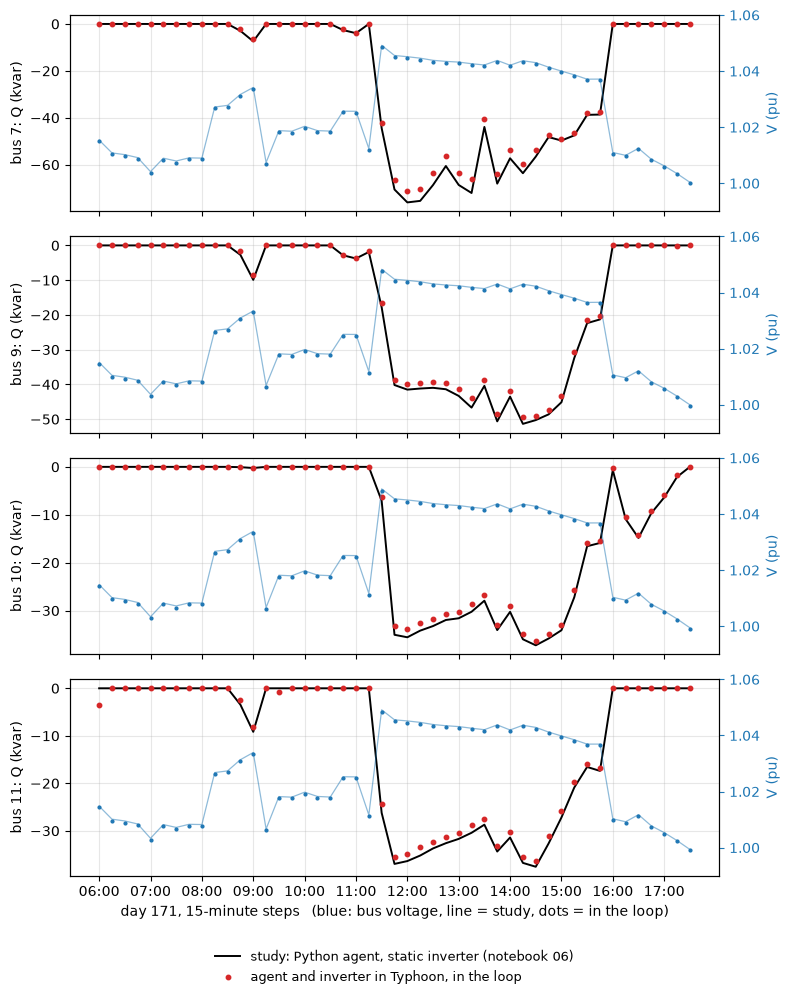

,mean |dV| (pu),max |dV| (pu),mean |dQ| (kvar),max |dQ| (kvar),"Q absorbed, study (kvarh)","Q absorbed, in the loop (kvarh)","V3 chosen, min-max"
bus,,,,,,,
7,0.00044,0.00068,1.30,6.07,266.4,251.1,1.015-1.030
9,0.00043,0.00066,0.68,2.82,185.0,177.0,1.010-1.030
10,0.00045,0.00070,0.53,1.77,144.7,138.5,1.001-1.030
11,0.00046,0.00071,0.63,3.58,139.9,134.6,1.012-1.030


In [4]:
x = np.arange(len(day)); tt = day.time.values
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)
for a, b in zip(axes, UNITS):
    a.plot(x, day[f"Q_study_{b}"], color="black", lw=1.4, label="study: Python agent, static inverter (notebook 06)")
    a.plot(x, day[f"Q_loop_{b}"], "o", color="tab:red", ms=3.2, label="agent and inverter in Typhoon, in the loop")
    a.set_ylabel(f"bus {b}: Q (kvar)"); a.grid(alpha=0.3)
    a2 = a.twinx(); a2.plot(x, day[f"V_study_{b}"], color="tab:blue", lw=0.9, alpha=0.5)
    a2.plot(x, day[f"V_loop_{b}"], ".", color="tab:blue", ms=4); a2.set_ylim(0.99, 1.06)
    a2.set_ylabel("V (pu)", color="tab:blue"); a2.tick_params(axis="y", colors="tab:blue")
axes[-1].set_xticks(x[::4]); axes[-1].set_xticklabels(tt[::4])
axes[-1].set_xlabel(f"day {DAY}, 15-minute steps   (blue: bus voltage, line = study, dots = in the loop)")
axes[-1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.32), ncol=1, frameon=False)
fig.tight_layout(); fig.savefig(os.path.join("../figures", "08_01_day.png"), dpi=150, bbox_inches="tight"); plt.show()

rows = []
for b in UNITS:
    dv = (day[f"V_study_{b}"] - day[f"V_loop_{b}"]).abs(); dq = (day[f"Q_study_{b}"] - day[f"Q_loop_{b}"]).abs()
    rows.append({"bus": b, "mean |dV| (pu)": round(dv.mean(), 5), "max |dV| (pu)": round(dv.max(), 5),
                 "mean |dQ| (kvar)": round(dq.mean(), 2), "max |dQ| (kvar)": round(dq.max(), 2),
                 "Q absorbed, study (kvarh)": round(-day[f"Q_study_{b}"].clip(upper=0).sum() * 0.25, 1),
                 "Q absorbed, in the loop (kvarh)": round(-day[f"Q_loop_{b}"].clip(upper=0).sum() * 0.25, 1),
                 "V3 chosen, min-max": f"{day[f'V3_{b}'].min():.3f}-{day[f'V3_{b}'].max():.3f}"})
pd.DataFrame(rows).set_index("bus")

The dots sit on the lines all day. The voltages agree to half a millivolt per unit and the
reactive powers to about one kvar, on units that absorb up to 75 kvar; the largest gap, six
kvar at bus 7 around noon, is the live agent asking a little less absorption because the
Typhoon inverter delivers about 2 % less active power than the lossless, perfectly tracking
PVSystem, so its bus rises a little less. The one stray dot, bus 11 at 06:00, is the first
decision of the day, built from the stand-in night state. At 15-minute resolution, the agent
on the inverter behaves as the agent in Python did, and the static inverter was a fair model.

## 5. The seconds the study never saw

At 11:30 the irradiance jumps from 0.28 to 0.93 pu within one step, the largest change of the
day. The capture starts with that step. The top panel is the terminal voltage of the four
inverters, the bottom their reactive power at feeder scale; the purple lines mark the moments
OpenDSS and Typhoon actually exchanged values, found from the trace itself (each exchange
takes about 1.25 s: the one-second wait plus reading, solving and writing).

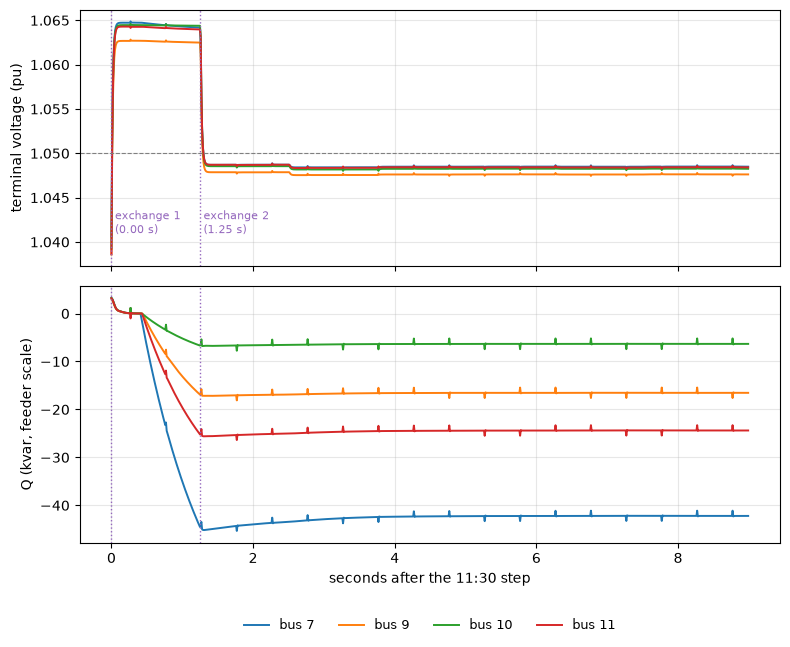

exchanges seen at t = [0.0, 1.25] s
highest terminal voltage 1.0649 pu; time above 1.05 pu 1.28 s per inverter
curve points chosen at this tick: bus 7 V3 = 1.030, bus 9 V3 = 1.030, bus 10 V3 = 1.030, bus 11 V3 = 1.030
bus 7: Q    1.1 ->  -42.2 kvar, settled within 5 % after 1.73 s
bus 9: Q    1.0 ->  -16.5 kvar, settled within 5 % after 1.15 s
bus 10: Q    1.1 ->   -6.3 kvar, settled within 5 % after 1.02 s
bus 11: Q    1.1 ->  -24.4 kvar, settled within 5 % after 1.14 s


In [5]:
t = tr.t_s.values
v7 = tr["V_pu_7"].values; jumps = np.where(np.abs(np.diff(v7)) > 0.0004)[0]
exchanges = [t[i] for k, i in enumerate(jumps) if k == 0 or i - jumps[k - 1] > 5]   # first sample of each rewrite
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)
for b in UNITS:
    axes[0].plot(t, tr[f"V_pu_{b}"], lw=1.4, label=f"bus {b}")
    axes[1].plot(t, tr[f"Q_var_{b}"] * SCALE[b] / 1e3, lw=1.4, label=f"bus {b}")
axes[0].axhline(1.05, color="grey", lw=0.8, ls="--"); axes[0].set_ylabel("terminal voltage (pu)")
axes[1].set_ylabel("Q (kvar, feeder scale)"); axes[1].set_xlabel("seconds after the 11:30 step")
for a in axes:
    a.grid(alpha=0.3)
    for e in exchanges:
        a.axvline(e, color="tab:purple", lw=1.0, ls=":")
for k, e in enumerate(exchanges):
    axes[0].text(e + 0.05, 1.041, f"exchange {k + 1}\n({e:.2f} s)", fontsize=8, color="tab:purple")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
fig.tight_layout(); fig.savefig(os.path.join("../figures", "08_02_transient.png"), dpi=150, bbox_inches="tight"); plt.show()

vmax = max(tr[f"V_pu_{b}"].max() for b in UNITS)
above = sum((tr[f"V_pu_{b}"] > 1.05).sum() for b in UNITS) / len(UNITS) * (t[1] - t[0])
print(f"exchanges seen at t = {[round(float(e), 2) for e in exchanges]} s")
print(f"highest terminal voltage {vmax:.4f} pu; time above 1.05 pu {above:.2f} s per inverter")
print("curve points chosen at this tick: " + ", ".join(f"bus {b} V3 = {tr[f'V3_out_{b}'].iloc[-1]:.3f}" for b in UNITS))
for b in UNITS:
    q = pd.Series(tr[f"Q_var_{b}"].values * SCALE[b] / 1e3).rolling(25, center=True, min_periods=1).median().values   # MPPT blips removed
    k0 = int(np.argmax(np.abs(np.diff(q)) > 0.05)) + 1
    qf = q[-100:].mean(); band = max(0.05 * abs(qf - q[k0]), 1.0)     # 5 % of the change, at least 1 kvar
    out = np.where(np.abs(q[k0:] - qf) > band)[0]
    print(f"bus {b}: Q {q[k0]:6.1f} -> {qf:6.1f} kvar, settled within 5 % after {t[k0 + out[-1] + 1] - t[k0]:.2f} s")

Reading the trace with the exchanges marked:

1. **Exchange 1 (0.0 s).** The tick has just raised: all four agents chose V3 = 1.03, the top of
   the allowed range. OpenDSS solves with the new sun but with the four Typhoon units' reactive
   power of the previous step, which was zero, and finds the far buses at 1.064 pu; that goes
   to the Typhoon sources, and the terminals follow within a few tens of milliseconds (the
   RMS measurement catching up).
2. **0.4 to 1.25 s.** The curve reads the voltage through its 1 s filter; the filtered value
   crosses V3 = 1.03 only after about 0.4 s, and from there the inverters ramp their absorption,
   bus 7 to 45 kvar.
3. **Exchange 2 (1.25 s).** That absorption is written into OpenDSS, which now finds 1.048 pu;
   the terminals drop at once, and the reactive power eases back to its settled value within
   about two seconds.
4. **Later exchanges** change nothing, so they leave no mark. The small blips every 0.5 s are
   the inverter's MPPT stepping its DC voltage, not exchanges.

So the far buses spent about a second above the limit that the study reports as never
crossed. Part of that is the loop, which changes the sun in one step where the real sky takes
seconds; but the point stands: "zero hours above 1.05 pu" is a 15-minute statement, and what
happens inside a minute is decided by how fast the local controller acts, which is a question
for real-time tests and not for a power-flow study.

## 6. What this adds to the study

1. **The agent runs on the inverter.** The actor of notebook 06, compiled into a C block on a
   dynamic inverter model, decides its own curve points from its own terminal every 15 minutes,
   and matches the PyTorch actor to better than 0.01 in any point.
2. **The day is reproduced.** With four such inverters in the loop and the same network deciding
   the other five in Python, the bus voltages agree with the study to 0.0005 pu and the
   reactive powers to about 1 kvar; the small systematic gap is the 2 % of active power that
   the static model does not lose.
3. **Curve points can be changed on a running inverter.** Every 15 minutes new points were
   written to running inverters with no jump in current and no trip; the reactive power moves
   to the new curve within about two seconds, the filter time plus the feeder's response.
4. **The 15-minute view hides seconds above the limit.** After a sharp irradiance rise the far
   buses spent about a second at 1.064 pu before the inverters pulled them back.
5. **Practical lessons.** Switch an inverter model on only after its PLL has locked; in a
   co-simulation hold the inverter's measured terminal, not its source, at the bus voltage, or
   the reactive power comes out 1.6 to 2 times too large; keep a network's weights out of the
   block code Typhoon parses itself; and four copies of a 128-unit network need the device's
   external memory.

What it does not add: real time. Virtual HIL runs the same model slower than the clock, so the
settling times are simulation seconds. Running the same model and loop on a HIL device is the
natural next step, and the model already targets one.

In [6]:
print(f"notebook time {time.perf_counter() - T_NB0:.0f} s")

notebook time 1 s
